# 特征选择、PCA 与模型比较

减少输入列既可能降低开销，也可能丢失用于判断攻击的信息。为了比较这两种变化，本节设置完整输入 Original、Pearson 特征选择 FS 和 PCA 三种表示，并分别使用决策树 DT、随机森林 RF。

单棵决策树可以展示按输入值逐层判断的路径。随机森林汇总多棵树，可以检查输入表示的变化在树集成中是否仍有类似影响。[DT 方法说明](https://scikit-learn.org/stable/modules/tree.html)和 [RF 方法说明](https://scikit-learn.org/stable/modules/ensemble.html#forest)支持这两种结构的区别。所以本项目选用 DT 和 RF，比较单树与树集成下的 FS、PCA 表现。两者都属于树模型，结论不能直接推广到距离模型或神经网络。模型参数固定，不将两者的成绩差异单独归因于集成。

Original 保留 02 已完成独热编码与 Min-Max 处理的全部 88 列。FS 选取其中部分列。PCA 将输入转换为主成分。比较只使用输入组合隔离划分，不使用普通分层划分。

不同版本的输入或标签不能混合比较。所以下一步读取 `data/processed/model_inputs.npz`，核对矩阵与记录信息。


In [1]:
# 1.读取隔离划分并核对输入和标签
from pathlib import Path
from time import perf_counter
import hashlib
import json 
import platform
import numpy as np
import pandas as pd
from IPython.display import display

root = Path.cwd().parent if Path.cwd().name == "experiment_steps" else Path.cwd()
input_path = root / "data" / "processed" / "model_inputs.npz"
assert input_path.is_file(), f"找不到隔离划分输入：{input_path}"
required_keys = {
    "group_X_train", "group_X_test", "group_y_train", "group_y_test",
    "group_train_index", "group_test_index", "group_train_type", "group_test_type",
    "group_feature_names", "input_fields", "raw_sha256", "random_seed", "schema_version",
}
with np.load(input_path, allow_pickle=False) as stored:
    assert set(stored.files) == required_keys, "文件内容与隔离划分交接约定不同"
    X_train = stored["group_X_train"].copy()
    X_test = stored["group_X_test"].copy()
    y_train = stored["group_y_train"].copy()
    y_test = stored["group_y_test"].copy()
    train_index = stored["group_train_index"].copy()
    test_index = stored["group_test_index"].copy()
    train_type = stored["group_train_type"].copy()
    test_type = stored["group_test_type"].copy()
    feature_names = stored["group_feature_names"].copy()
    input_columns = stored["input_fields"].copy()
    raw_sha256 = stored["raw_sha256"].item()
    random_seed = int(stored["random_seed"].item())
    schema_version = stored["schema_version"].item()

expected_sha256 = "65d5465df1809b984fd10e4703bc9c012d1aefd11803773856364216f0a3520d"
assert raw_sha256 == expected_sha256 and schema_version == "1"
assert X_train.shape == (360464, 88) and X_test.shape == (89508, 88)
assert X_train.dtype == np.float64 and X_test.dtype == np.float64
assert len(feature_names) == 88 and len(set(feature_names)) == 88
assert len(input_columns) == 38
assert not set(input_columns) & {"label", "type", "ts", "src_ip", "dst_ip", "src_port", "dst_port"}
for matrix, labels, indices, types in [
    (X_train, y_train, train_index, train_type),
    (X_test, y_test, test_index, test_type),
]:
    assert matrix.shape[0] == len(labels) == len(indices) == len(types)
    assert set(np.unique(labels)) == {0, 1}
    assert np.array_equal(labels, (types != "normal").astype(np.int8))
    assert np.isfinite(matrix).all()
assert not np.intersect1d(train_index, test_index).size
train_hash = pd.util.hash_pandas_object(pd.DataFrame(X_train), index=False)
test_hash = pd.util.hash_pandas_object(pd.DataFrame(X_test), index=False)
shared_input_rows = int(test_hash.isin(set(train_hash)).sum())
assert shared_input_rows == 0, "当前输入中出现跨训练集和测试集的相同组合候选"
del train_hash, test_hash
train_digest = hashlib.sha256(X_train.tobytes()).hexdigest()
test_digest = hashlib.sha256(X_test.tobytes()).hexdigest()
input_sha256 = hashlib.sha256(input_path.read_bytes()).hexdigest()

def show_table(table, decimals=6):
    with pd.option_context("display.max_rows", None, "display.max_columns", None,
                           "display.max_colwidth", None):
        display(table.style.format(precision=decimals).hide(axis="index"))

input_summary = pd.DataFrame({
    "数据": ["隔离训练集", "隔离测试集"],
    "记录数": [len(y_train), len(y_test)],
    "输入列数": [X_train.shape[1], X_test.shape[1]],
    "正常记录数": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "攻击记录数": [int((y_train == 1).sum()), int((y_test == 1).sum())],
    "攻击比例": [y_train.mean(), y_test.mean()],
})
show_table(input_summary)
type_distribution = pd.concat([
    pd.Series(train_type).value_counts().rename("训练记录数"),
    pd.Series(test_type).value_counts().rename("测试记录数"),
], axis=1).fillna(0).astype(int).rename_axis("流量类型").reset_index()
show_table(type_distribution)

数据,记录数,输入列数,正常记录数,攻击记录数,攻击比例
隔离训练集,360464,88,230538,129926,0.360441
隔离测试集,89508,88,58391,31117,0.347645


流量类型,训练记录数,测试记录数
normal,230538,58391
scanning,16723,3277
xss,16369,3631
dos,16000,4000
injection,16000,4000
ddos,16000,4000
password,16000,4000
ransomware,16000,4000
backdoor,16000,4000
mitm,834,209


结论：通过数据项、形状和标签对应检查，两侧各有 88 列输入，当前矩阵的跨集合输入指纹候选数为 0。训练集有 360,464 条记录，测试集有 89,508 条记录。上表展示全部十种流量类型，标签仍是 0 表示正常、1 表示攻击。

相同模型若随输入方案改变参数，就难以判断变化来自输入表示还是模型设置。所以下一步需要固定模型参数和评价口径。

检测模型的选择理由已在开头说明。这里进一步固定分支规则、模型规模和评价口径。

Gini 衡量节点中类别的混杂程度，可用于正常与攻击的分支比较。[DT 参数说明](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)给出了分支及停止条件。为了固定可重复的基础配置，DT 采用 Gini，不设置最大深度。没有深度上限不表示无限生长，节点纯度、样本数及可用分支仍会限制生长。

为了控制单棵树的规模与本次计算量，RF 固定为 100 棵树，最大深度为 5，使用四个并行任务。这些是固定实验设置，尚未证明最优。两种模型的随机种子均为 42，同一模型在全部输入方案中保持相同参数。[RF 参数说明](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)可核对完整含义。

正常与攻击数量不同，只看准确率可能忽略攻击漏报。所以下一步固定 Macro-F1 与攻击召回率为主要指标，同时保留其他分数和四类计数。[指标定义](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)说明了以下计算口径。本次将攻击 `1` 作为正类，正常 `0` 作为负类。

| 计数 | 真实类别 | 预测类别 | 含义 |
| --- | --- | --- | --- |
| TP | 攻击 | 攻击 | 攻击检出 |
| TN | 正常 | 正常 | 正常判断正确 |
| FP | 正常 | 攻击 | 正常误报 |
| FN | 攻击 | 正常 | 攻击漏报 |

攻击召回率 = TP ÷ (TP + FN)，表示实际攻击中被检出的比例。

攻击精确率 = TP ÷ (TP + FP)，表示预测为攻击的记录中，确实属于攻击的比例。

Accuracy = (TP + TN) ÷ 全部记录数。

每类 F1 综合该类的精确率与召回率。Macro-F1 = (正常 F1 + 攻击 F1) ÷ 2，两类等权。

Weighted-F1 = (实际正常记录数 × 正常 F1 + 实际攻击记录数 × 攻击 F1) ÷ 全部记录数。权重来自真实类别数量，不是预测正确的数量。

MCC（马修斯相关系数）同时考虑四类计数：

$$
\mathrm{MCC} =
\frac{TP \times TN - FP \times FN}
{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}
$$

在公式可计算的情况下，1 表示预测完全一致，−1 表示完全相反。接近 0 表示这种对应关系较弱，不能单凭该值认定模型使用了随机预测，也不能将 MCC 当作正确记录的百分比。

混淆矩阵的行表示真实类别，列表示预测类别。这里两侧顺序均为正常、攻击，位置为：

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

为了区分输入处理与模型计算的开销，分别记录训练准备、测试转换、模型训练和模型预测时间。训练总时间 = 训练准备 + 模型训练。测试总时间 = 测试转换 + 模型预测。

02 的数据准备、文件读取、指标计算和绘图不计入本轮时间。每次计时处理完整集合，批量耗时不等于单条流量的在线响应时间。


In [2]:
# 2.固定模型参数、评价指标和计时口径
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix,
)
from threadpoolctl import threadpool_limits

model_factories = {
    "DT": lambda: DecisionTreeClassifier(criterion="gini", max_depth=None,
                                         random_state=random_seed),
    "RF": lambda: RandomForestClassifier(n_estimators=100, criterion="gini",
                                         max_depth=5, n_jobs=4, random_state=random_seed),
}
parameter_rows = []
for model_name, factory in model_factories.items():
    for parameter, value in factory().get_params().items():
        parameter_rows.append({"模型": model_name, "参数": parameter, "取值": str(value)})
model_parameters = pd.DataFrame(parameter_rows)
show_table(model_parameters)
result_rows = []
predictions = {}
trained_models = {}

def evaluate_model(model_name, method, dimensions, train_values, test_values,
                   train_prepare_seconds=0.0, test_transform_seconds=0.0,
                   threshold=None):
    estimator = model_factories[model_name]()
    with threadpool_limits(limits=4):
        start = perf_counter()
        estimator.fit(train_values, y_train)
        train_seconds = perf_counter() - start
        start = perf_counter()
        predicted = estimator.predict(test_values).astype(np.int8)
        predict_seconds = perf_counter() - start
    tn, fp, fn, tp = confusion_matrix(y_test, predicted, labels=[0, 1]).ravel()
    assert int(tn + fp + fn + tp) == len(y_test)
    attack_recall = recall_score(y_test, predicted, pos_label=1, zero_division=0)
    assert np.isclose(attack_recall, tp / (tp + fn))
    record = {
        "模型": model_name, "输入方案": method, "维数": dimensions,
        "Pearson阈值": np.nan if threshold is None else threshold,
        "Macro-F1": f1_score(y_test, predicted, average="macro", zero_division=0),
        "攻击召回率": attack_recall,
        "攻击精确率": precision_score(y_test, predicted, pos_label=1, zero_division=0),
        "Accuracy": accuracy_score(y_test, predicted),
        "Weighted-F1": f1_score(y_test, predicted, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y_test, predicted),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "训练准备秒": train_prepare_seconds, "测试转换秒": test_transform_seconds,
        "模型训练秒": train_seconds, "模型预测秒": predict_seconds,
        "训练总秒": train_prepare_seconds + train_seconds,
        "测试总秒": test_transform_seconds + predict_seconds,
        "随机种子": random_seed,
    }
    key = f"{model_name}_{method}_{dimensions}"
    assert key not in predictions
    predictions[key] = predicted
    trained_models[key] = estimator
    result_rows.append(record)
    print(f"完成 {model_name} × {method}，输入 {dimensions} 维")
    return record

模型,参数,取值
DT,ccp_alpha,0.0
DT,class_weight,None
DT,criterion,gini
DT,max_depth,None
DT,max_features,None
DT,max_leaf_nodes,None
DT,min_impurity_decrease,0.0
DT,min_samples_leaf,1
DT,min_samples_split,2
DT,min_weight_fraction_leaf,0.0


结论：输出列了 DT 和 RF 的全部参数。指标函数与计时边界已固定。同一模型在各输入方案中使用相同配置。RF 的默认候选列规则为 `sqrt`，实际候选列数量会随输入维数变化，这属于固定规则下的模型行为。

没有全部输入的基线，就无法判断减少输入后是否改善了检测效果或耗时。所以下一步先训练 Original。

In [3]:
# 3.训练全部 88 列输入的 Original 基线
# 核对本轮使用第 2 步确定的固定设置
assert model_factories["DT"]().get_params()["criterion"] == "gini"
assert model_factories["DT"]().get_params()["max_depth"] is None
assert model_factories["RF"]().get_params()["n_estimators"] == 100
assert model_factories["RF"]().get_params()["max_depth"] == 5
baseline_rows = []
for model_name in model_factories:
    baseline_rows.append(evaluate_model(model_name, "Original", X_train.shape[1],
                                        X_train, X_test))
baseline_results = pd.DataFrame(baseline_rows)
show_table(baseline_results)

完成 DT × Original，输入 88 维


完成 RF × Original，输入 88 维


模型,输入方案,维数,Pearson阈值,Macro-F1,攻击召回率,攻击精确率,Accuracy,Weighted-F1,MCC,TN,FP,FN,TP,训练准备秒,测试转换秒,模型训练秒,模型预测秒,训练总秒,测试总秒,随机种子
DT,Original,88,nan,0.915203,0.985089,0.820476,0.919884,0.921274,0.840390,51684,6707,464,30653,0.000000,0.000000,1.042022,0.012081,1.042022,0.012081,42
RF,Original,88,nan,0.837757,0.986920,0.690516,0.841679,0.845443,0.715490,44627,13764,407,30710,0.000000,0.000000,3.646590,0.069063,3.646590,0.069063,42


结论：Original 使用全部 88 列输入。DT 的 Macro-F1 为 0.915203，攻击召回率为 0.985089。RF 对应为 0.837757 和 0.986920。精确率、误报和漏报也列在上表，整体表现需要结合这些结果判断。

DT 未预设最大深度，RF 每棵树的最大深度为 5。两者的结构和规模设置不同。所以这里的差异只代表当前配置，不能直接证明 DT 优于 RF。本轮在每种模型内部比较 Original、FS 和 PCA。[DT 深度参数说明](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)和 [RF 参数说明](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)解释了这些设置。

01 已观察到 `weird_name` 与 `weird_notice` 的出现信息重合。其他输入之间是否也有相近的变化，还需要检查。所以下一步只用训练集计算 Pearson 相关矩阵。

两列输入可能一起增大，也可能一列增大、另一列减小。Pearson 系数可以描述这种线性关系，范围为 −1 到 1。

接近 1 表示较强的同向关系

接近 −1 表示较强的反向关系

接近 0 只表示线性关系弱，不能证明两列独立。[NumPy 计算说明](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html)给出了本段函数的定义。

恒定列没有取值变化，无法按通常公式计算 Pearson 系数。
所以先检查训练集是否存在恒定列。检查通过后，再计算全部输入之间的相关关系。

每列会得到与全部 88 列的相关系数。为了形成一套固定的候选选列规则，本次对各列的相关系数保留正负号后取平均。这是当前选择的评分方式，不是 Pearson 分析必须采用的步骤。这就是表中的“平均有符号相关”。平均值包括与自身的相关系数 1，贡献为 `1/88`。[参考论文](https://link.springer.com/article/10.1186/s40537-024-00892-y)介绍了按平均相关分数形成候选的思路。当前是否计入自相关及选列范围，以这里的定义和代码为准。

注：正相关与负相关可能抵消。所以平均分数接近零，既不能直接证明没有重复表达的信息，也不能证明该列对检测重要。本段计算的是输入之间的关系，没有计算输入与攻击标签的相关程度。

为了检查平均分数是否掩盖较强的两两关系，再计算与其他列的平均绝对相关和最大绝对相关。取绝对值后，同向和反向关系不会互相抵消。这两项只用于检查，选列仍使用平均有符号相关。

接下来展示全部 88 列的分数和完整相关图。

输入列名,平均有符号相关,与其他列平均绝对相关,与其他列最大绝对相关
duration,0.026502,0.018449,0.466299
src_bytes,0.022962,0.013518,0.660927
dst_bytes,0.021867,0.012593,0.660927
missed_bytes,0.016784,0.006827,0.222826
src_pkts,0.034287,0.026608,0.892101
src_ip_bytes,0.028726,0.019453,0.892101
dst_pkts,0.032286,0.023356,0.629951
dst_ip_bytes,0.031698,0.025855,0.629951
dns_qclass,0.012885,0.024527,0.173213
dns_qtype,0.017270,0.068115,0.449931


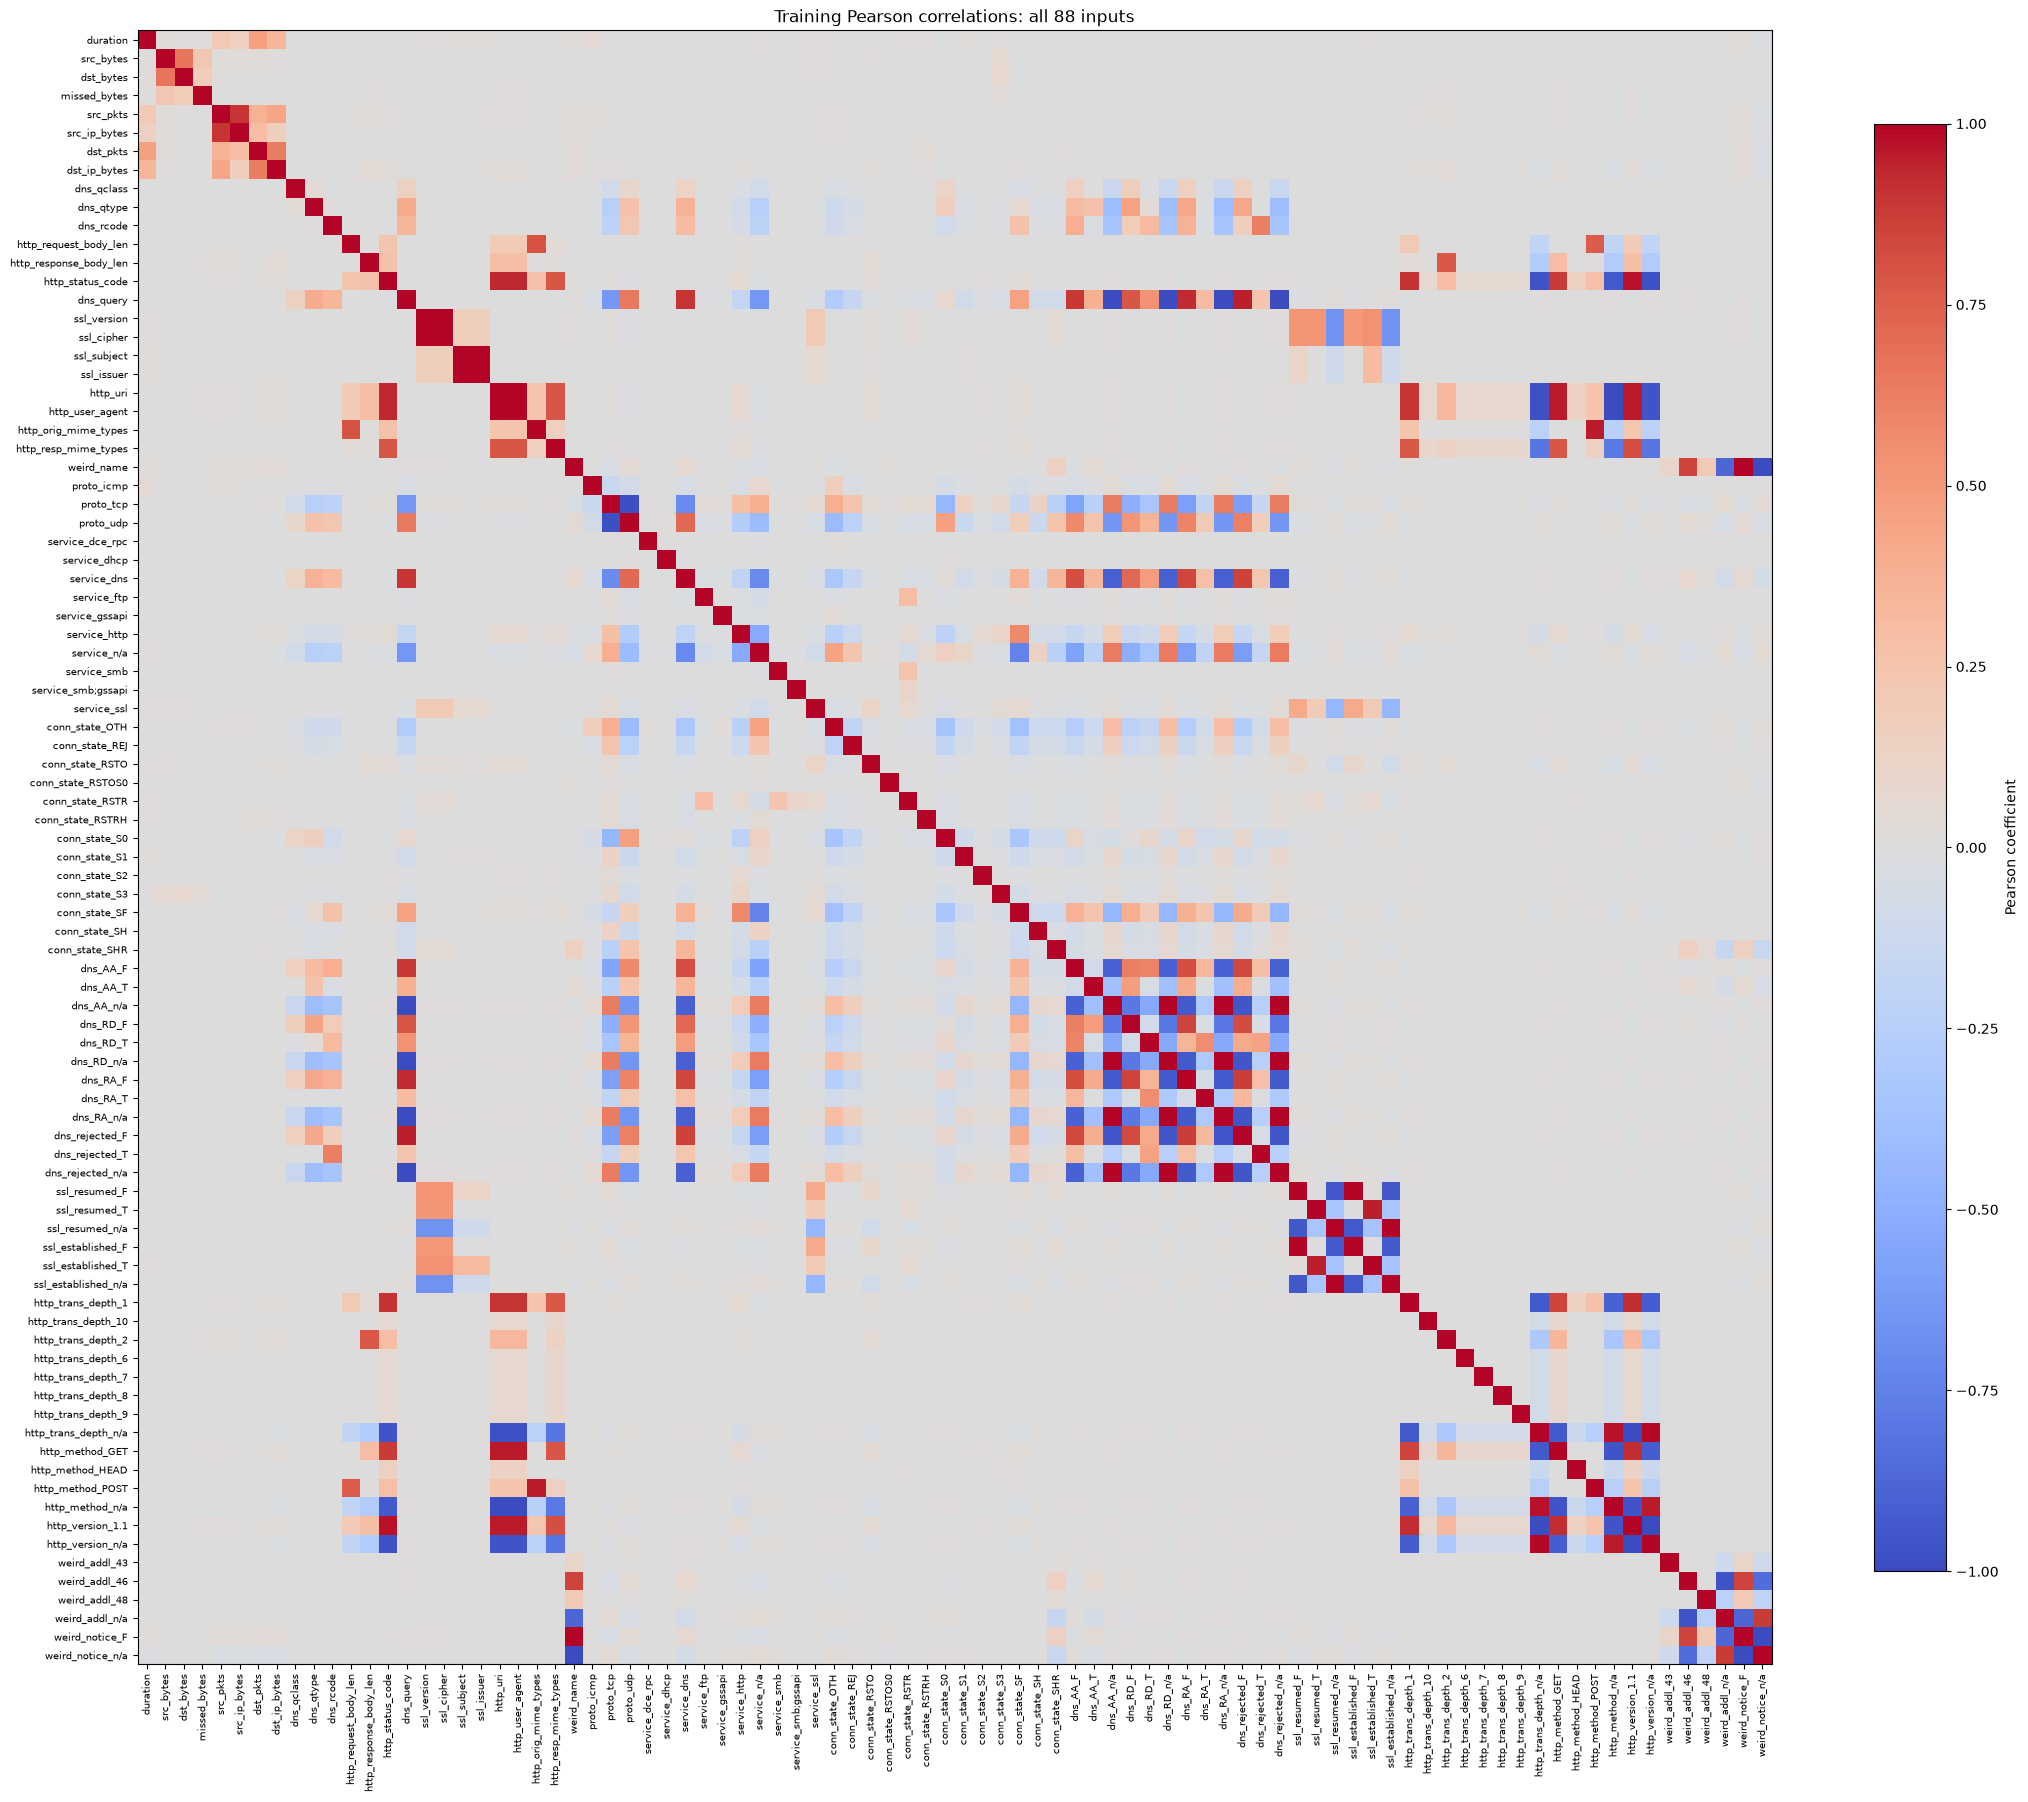

In [4]:
# 4.计算训练集 Pearson 关系并展示全部输入的分数
# 没有取值变化的列不能按通常公式计算相关系数
start = perf_counter()
constant_columns = feature_names[np.ptp(X_train, axis=0) == 0]
assert not len(constant_columns), f"恒定列无法直接计算 Pearson 系数：{constant_columns.tolist()}"
with threadpool_limits(limits=4):
    correlation_matrix = np.corrcoef(X_train, rowvar=False)
assert np.isfinite(correlation_matrix).all()
assert np.allclose(correlation_matrix, correlation_matrix.T)
assert np.allclose(np.diag(correlation_matrix), 1)
correlation_scores = correlation_matrix.mean(axis=0)
correlation_seconds = perf_counter() - start
other_correlations = correlation_matrix.copy()
np.fill_diagonal(other_correlations, np.nan)
feature_scores = pd.DataFrame({
    "输入列名": feature_names,
    "平均有符号相关": correlation_scores,
    "与其他列平均绝对相关": np.nanmean(np.abs(other_correlations), axis=0),
    "与其他列最大绝对相关": np.nanmax(np.abs(other_correlations), axis=0),
})
show_table(feature_scores)
correlation_table = pd.DataFrame(correlation_matrix, index=feature_names, columns=feature_names)

fig_correlation, ax = plt.subplots(figsize=(22, 20))
image = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(np.arange(len(feature_names)), feature_names, rotation=90, fontsize=7)
ax.set_yticks(np.arange(len(feature_names)), feature_names, fontsize=7)
ax.set_title("Training Pearson correlations: all 88 inputs")
fig_correlation.colorbar(image, ax=ax, shrink=0.75, label="Pearson coefficient")
fig_correlation.tight_layout()
plt.show()

结论：恒定列检查通过，评分表和相关图均由训练集的全部 88 列计算。测试集未参与。表中平均有符号相关保留正负号，另外两项使用绝对值。它们衡量的内容不同，不能相互替代。

为了得到可比较的候选列集合，并避免按测试成绩反复选列，下一步使用固定阈值筛选平均有符号相关分数。

放宽分数范围，可以保留更多或相同数量的列。为了比较不同保留程度，本次设置逐步扩大的对称范围。阈值为 0.01、0.015、0.02、0.03 和 0.1。每个范围保留分数位于 −阈值到阈值的列。[参考论文](https://link.springer.com/content/pdf/10.1186/s40537-024-00892-y.pdf#page=25)提供了这组候选阈值的来源。

这些阈值属于固定的实验设置，尚无证据说明它们最适合当前数据。不同阈值可能选出同一集合，也可能没有入选列。所以先核对实际数量，再决定哪些候选可以进入比较。

若某范围保留全部输入，它与 Original 相同。若两个范围选出同一集合，也没有形成新的输入方案。为了避免重复计算，这两种情况不重复训练。没有入选列的情况只记录数量。

下面展示全部五个范围的数量。入选列明细只列分数落在对应范围内的列，未列出的列不满足该范围。这里的入选表示满足规则，不表示已经证实预测效果较好。

In [5]:
# 5.生成并核对各 Pearson 阈值对应的列集合
# 先按固定范围选列，再核对空集合、重复集合和全部输入
thresholds = [0.01, 0.015, 0.02, 0.03, 0.1]
selection_rows = []
selected_rows = []
fs_specs = []
used_column_sets = set()
for threshold in thresholds:
    selection_start = perf_counter()
    positions = np.flatnonzero(np.abs(correlation_scores) <= threshold)
    selection_seconds = perf_counter() - selection_start
    signature = tuple(positions.tolist())
    if len(positions) == X_train.shape[1]:
        status = "全部输入，与 Original 相同"
    elif not len(positions):
        status = "没有入选列，不训练"
    elif signature in used_column_sets:
        status = "与已有候选相同，不重复训练"
    else:
        status = "用于 FS 与同维数 PCA 比较"
        fs_specs.append({"threshold": threshold, "positions": positions,
                         "selection_seconds": selection_seconds})
        used_column_sets.add(signature)
    selection_rows.append({"阈值": threshold, "下界": -threshold, "上界": threshold,
                           "入选列数": len(positions), "处理": status})
    for position in positions:
        selected_rows.append({"阈值": threshold, "输入列名": feature_names[position],
                              "平均有符号相关": correlation_scores[position]})
threshold_summary = pd.DataFrame(selection_rows)
selected_features = pd.DataFrame(selected_rows)
assert fs_specs, "当前阈值没有形成可比较的降维候选"
assert len({len(spec["positions"]) for spec in fs_specs}) == len(fs_specs), "相同维数的不同集合需单独命名"
show_table(threshold_summary)
show_table(selected_features)

阈值,下界,上界,入选列数,处理
0.010000,-0.010000,0.010000,10,用于 FS 与同维数 PCA 比较
0.015000,-0.015000,0.015000,33,用于 FS 与同维数 PCA 比较
0.020000,-0.020000,0.020000,45,用于 FS 与同维数 PCA 比较
0.030000,-0.030000,0.030000,69,用于 FS 与同维数 PCA 比较
0.100000,-0.100000,0.100000,88,全部输入，与 Original 相同


阈值,输入列名,平均有符号相关
0.010000,proto_icmp,0.006575
0.010000,service_http,-0.001015
0.010000,conn_state_REJ,-0.006386
0.010000,conn_state_RSTRH,0.008300
0.010000,conn_state_S0,-0.006347
0.010000,conn_state_S1,0.002704
0.010000,conn_state_S2,0.009910
0.010000,conn_state_S3,0.008342
0.010000,conn_state_SH,0.001452
0.010000,conn_state_SHR,0.005609


结论：阈值 0.01、0.015、0.02、0.03 和 0.1 分别保留 10、33、45、69 和 88 列。最后一个范围保留全部输入，与 Original 相同。所以降维比较使用前四套候选，维数为 10、33、45、69。上表展示全部入选列，但还没有这些方案的检测结果。

训练和测试若使用不同的列或顺序，同一位置就可能表示不同信息。

所以下一步按训练集选定的列和顺序，提取两侧的 FS 输入。

In [6]:
# 6.按相同列顺序生成 FS 训练和测试输入
# 两侧使用同一组位置，保持入选列的含义与顺序一致
fs_inputs = {}
fs_shape_rows = []
for spec in fs_specs:
    positions = spec["positions"]
    dimensions = len(positions)
    start = perf_counter()
    train_values = np.ascontiguousarray(X_train[:, positions])
    train_select_seconds = perf_counter() - start
    start = perf_counter()
    test_values = np.ascontiguousarray(X_test[:, positions])
    test_select_seconds = perf_counter() - start
    assert train_values.shape == (len(y_train), dimensions)
    assert test_values.shape == (len(y_test), dimensions)
    fs_inputs[dimensions] = {
        "train": train_values, "test": test_values,
        "names": feature_names[positions], "threshold": spec["threshold"],
        "train_seconds": correlation_seconds + spec["selection_seconds"] + train_select_seconds,
        "test_seconds": test_select_seconds,
    }
    fs_shape_rows.append({"阈值": spec["threshold"], "输入列数": dimensions,
                          "训练形状": str(train_values.shape), "测试形状": str(test_values.shape)})
show_table(pd.DataFrame(fs_shape_rows))

阈值,输入列数,训练形状,测试形状
0.010000,10,"(360464, 10)","(89508, 10)"
0.015000,33,"(360464, 33)","(89508, 33)"
0.020000,45,"(360464, 45)","(89508, 45)"
0.030000,69,"(360464, 69)","(89508, 69)"


结论：四套 FS 输入的记录数保持不变。每套方案的训练与测试都使用相同列和顺序。FS 保留入选列中的原有数值。

训练准备时间包括相关分数计算和选列。相关分数实际只计算一次，但每套候选按独立使用该方案的口径计入这项开销。所以不能把各候选的准备时间相加，当作本次实际总耗时。

维数不同会改变压缩程度。为了在相同输入数量下比较两种表示，下一步建立与各套 FS 维数相同的 PCA 输入。

FS 保留已有列。另一种减少维数的方式，是把多个输入组合成较少的新输入。为了比较这两种表示，采用 PCA 生成主成分。

每个主成分是原有输入的线性组合。PCA 优先保留方差较大的方向，不使用攻击标签选择方向。方差表示数据在该方向上的变化程度，不能直接说明攻击是否容易区分。[PCA 方法说明](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)给出了转换定义。

02 已用隔离训练集的范围完成 Min-Max 处理。为了让三种方案从相同输入出发，PCA 使用这份矩阵。PCA 会减去训练均值，但不会自动将各列除以标准差。所以当前结果仍受原有缩放方式影响。

为了与 FS 保持相同的输入列数，前四套 PCA 的主成分数分别等于对应 FS 的实际列数。为了避免随机近似影响主成分方向，计算使用完整 SVD。为了保留主成分原有的方差差异，不启用白化，不再把各主成分的方差统一为 1。

仅比较降维后的 PCA，无法区分减少维数与改变坐标方向的影响。所以另外保留全部 88 个主成分，与 Original 88 列比较。这是完整维数的表示对照，不属于降维。完整 PCA 保留输入的线性表示，但树按各列分别设置分支，转换方向后预测仍可能变化。[参考论文](https://link.springer.com/article/10.1186/s40537-024-00892-y#Sec12)包含完整输入的 FS 与 PCA 对照；本次维数由实际输入确定。

接下来是全部主成分的方差比例。五套候选分别绘图，每张图包含该方案保留的全部主成分。代码同时生成全部组合系数，用于追溯每个主成分由哪些输入组成。组合系数不直接表示攻击检测重要性。


主成分数,训练形状,测试形状,累计解释方差
10,"(360464, 10)","(89508, 10)",0.949925
33,"(360464, 33)","(89508, 33)",0.999522
45,"(360464, 45)","(89508, 45)",0.999952
69,"(360464, 69)","(89508, 69)",1.000000
88,"(360464, 88)","(89508, 88)",1.000000


方案维数,主成分,主成分序号,解释方差比例,累计解释方差
10,PC1,1,0.545198,0.545198
10,PC2,2,0.134102,0.679300
10,PC3,3,0.094231,0.773532
10,PC4,4,0.046404,0.819936
10,PC5,5,0.035816,0.855752
10,PC6,6,0.032453,0.888205
10,PC7,7,0.022575,0.910780
10,PC8,8,0.015479,0.926259
10,PC9,9,0.012627,0.938886
10,PC10,10,0.011040,0.949925


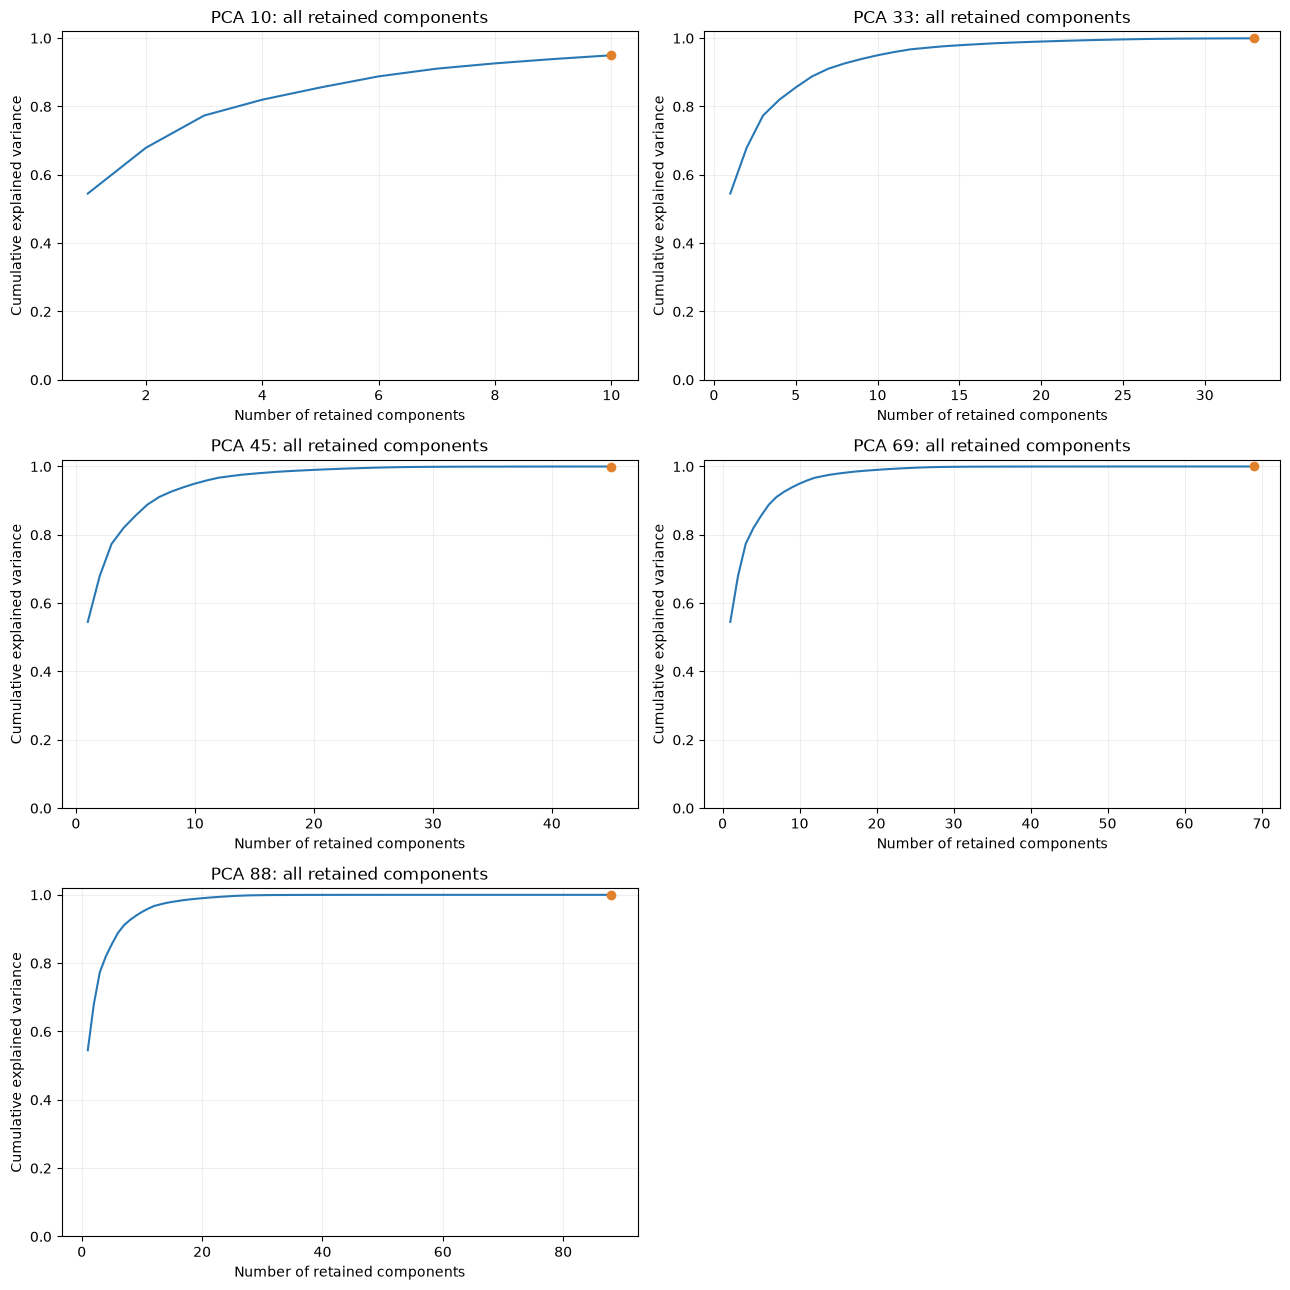

In [7]:
# 7.仅在训练集生成五套 PCA 并展示全部方差比例
# 主成分方向只根据训练记录确定，测试记录使用相同转换
pca_inputs = {}
pca_variance_rows = []
pca_loading_rows = []
pca_shape_rows = []
pca_dimensions = [*fs_inputs, X_train.shape[1]]
for dimensions in pca_dimensions:
    pca = PCA(n_components=dimensions, svd_solver="full", whiten=False, copy=True)
    with threadpool_limits(limits=4):
        start = perf_counter()
        train_values = pca.fit_transform(X_train)
        train_prepare_seconds = perf_counter() - start
        start = perf_counter()
        test_values = pca.transform(X_test)
        test_transform_seconds = perf_counter() - start
    assert train_values.shape == (len(y_train), dimensions)
    assert test_values.shape == (len(y_test), dimensions)
    assert np.isfinite(train_values).all() and np.isfinite(test_values).all()
    pca_inputs[dimensions] = {
        "train": train_values, "test": test_values, "pca": pca,
        "train_seconds": train_prepare_seconds, "test_seconds": test_transform_seconds,
    }
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    pca_shape_rows.append({"主成分数": dimensions, "训练形状": str(train_values.shape),
                          "测试形状": str(test_values.shape), "累计解释方差": cumulative[-1]})
    for position, (ratio, total) in enumerate(zip(pca.explained_variance_ratio_, cumulative)):
        component = f"PC{position + 1}"
        pca_variance_rows.append({"方案维数": dimensions, "主成分": component,
                                  "主成分序号": position + 1, "解释方差比例": ratio,
                                  "累计解释方差": total})
        for name, coefficient in zip(feature_names, pca.components_[position]):
            pca_loading_rows.append({"方案维数": dimensions, "主成分": component,
                                     "输入列名": name, "组合系数": coefficient})
pca_variance = pd.DataFrame(pca_variance_rows)
pca_loadings = pd.DataFrame(pca_loading_rows)
show_table(pd.DataFrame(pca_shape_rows))
show_table(pca_variance)
fig_variance, axes = plt.subplots(3, 2, figsize=(13, 13))
for ax, (dimensions, group) in zip(axes.ravel(), pca_variance.groupby("方案维数", sort=False)):
    ax.plot(group["主成分序号"], group["累计解释方差"], color="#2878B5")
    ax.scatter(group["主成分序号"].iloc[-1], group["累计解释方差"].iloc[-1],
               color="#E1812C", zorder=3)
    ax.set_xlabel("Number of retained components")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_ylim(0, 1.02)
    ax.set_title(f"PCA {dimensions}: all retained components")
    ax.grid(alpha=0.2)
for ax in axes.ravel()[len(pca_dimensions):]:
    ax.set_visible(False)
fig_variance.tight_layout()
plt.show()

结论：PCA 共生成 10、33、45、69、88 维五套输入。前四套与 FS 同维数配对。88 维与 Original 比较。全部主成分的解释方差比例见上表，它描述训练数据的变化，不代表攻击检测准确率。

输入形状已核对，所以下一步使用固定的 DT、RF 参数训练这些方案，检查不同表示的检测表现。


In [8]:
# 8.训练四套 FS 与五套 PCA 的 DT、RF
for method, inputs in [("FS", fs_inputs), ("PCA", pca_inputs)]:
    for dimensions, values in inputs.items():
        for model_name in model_factories:
            evaluate_model(
                model_name, method, dimensions, values["train"], values["test"],
                values["train_seconds"], values["test_seconds"],
                values.get("threshold"),
            )
reduced_results = pd.DataFrame(result_rows)[lambda table: table["输入方案"] != "Original"]
show_table(reduced_results)

完成 DT × FS，输入 10 维


完成 RF × FS，输入 10 维


完成 DT × FS，输入 33 维


完成 RF × FS，输入 33 维


完成 DT × FS，输入 45 维


...

完成 DT × PCA，输入 69 维


完成 RF × PCA，输入 69 维


完成 DT × PCA，输入 88 维


完成 RF × PCA，输入 88 维


模型,输入方案,维数,Pearson阈值,Macro-F1,攻击召回率,攻击精确率,Accuracy,Weighted-F1,MCC,TN,FP,FN,TP,训练准备秒,测试转换秒,模型训练秒,模型预测秒,训练总秒,测试总秒,随机种子
DT,FS,10,0.010000,0.757752,0.758428,0.647196,0.772289,0.775834,0.521537,45526,12865,7517,23600,0.208550,0.003265,0.055779,0.002036,0.264329,0.005301,42
RF,FS,10,0.010000,0.721745,0.540219,0.710512,0.763641,0.754645,0.456732,51542,6849,14307,16810,0.208550,0.003265,1.761628,0.044669,1.970178,0.047934,42
DT,FS,33,0.015000,0.773793,0.805444,0.655602,0.785271,0.789319,0.558350,45225,13166,6054,25063,0.248006,0.011385,0.225765,0.002977,0.473770,0.014362,42
RF,FS,33,0.015000,0.732269,0.561462,0.718498,0.771071,0.763326,0.475599,51546,6845,13646,17471,0.248006,0.011385,2.402493,0.045680,2.650499,0.057065,42
DT,FS,45,0.020000,0.792393,0.849279,0.669190,0.801649,0.805750,0.599961,45327,13064,4690,26427,0.338206,0.018264,0.268888,0.003526,0.607094,0.021789,42
RF,FS,45,0.020000,0.785665,0.867821,0.652538,0.793404,0.798075,0.593696,44012,14379,4113,27004,0.338206,0.018264,2.722804,0.047304,3.061010,0.065568,42
DT,FS,69,0.030000,0.908272,0.973134,0.814115,0.913416,0.914891,0.825945,51477,6914,836,30281,0.417838,0.023293,0.770851,0.005678,1.188690,0.028971,42
RF,FS,69,0.030000,0.790949,0.880580,0.656311,0.798174,0.802792,0.606017,44042,14349,3716,27401,0.417838,0.023293,3.505376,0.058095,3.923214,0.081388,42
DT,PCA,10,nan,0.793275,0.848893,0.670738,0.802599,0.806653,0.601361,45424,12967,4702,26415,1.766486,0.013918,0.227764,0.002348,1.994250,0.016266,42
RF,PCA,10,nan,0.790920,0.849761,0.666683,0.800074,0.804250,0.597593,45171,13220,4675,26442,1.766486,0.013918,2.242332,0.044767,4.008818,0.058684,42


结论：四套 FS 与五套 PCA 均完成 DT、RF 训练。上表展示全部 18 个非 Original 实验，其中两个 PCA 88 维实验不减少输入数量。

这张表未加入 Original，也未计算方案差值。为了核对基线与表示对照，下一步汇总全部 20 个实验。


为了比较降维方案与完整输入的差别，第一张表将加入两个 Original 基线，汇总全部 20 个实验。表格末尾将增加四列“相对Original的……变化”，分别对应 Macro-F1、攻击召回率、训练总秒和测试总秒。差值按当前方案减去同模型的 Original 计算。

为了比较相同维数下两种输入表示的差别，第二张表将列出全部八组 FS 与 PCA 配对。四个差值列名以“PCA减FS的……”开头，按同模型、同维数的 PCA 结果减去 FS 结果计算。两张表中，分数差值为正表示前者分数更高，时间差值为正表示前者耗时更长。

测试分数不能反映模型在训练记录上的表现，参数中的深度上限也不等于实际树深。所以第四张表将检查全部 20 个实验的训练与测试分数、树数量、树深范围和平均叶子数。RF 的树深范围和平均叶子数将根据全部 100 棵树计算。用于这项检查的预测不计入训练和测试总时间。
PCA 88 维没有对应的降维 FS。它与同模型的 Original 比较，差值单独成表。这样可以核对维数不变时转换主成分方向的影响。


In [9]:
# 9.汇总全部实验并核对模型表现
# 汇总测试成绩之外，还检查训练成绩和全部已训练树的规模
# 这些检查不调整模型，也不计入第 2 步定义的训练与预测时间
results_summary = pd.DataFrame(result_rows)
assert len(results_summary) == 2 + 2 * len(fs_inputs) + 2 * len(pca_inputs)
assert not results_summary.duplicated(["模型", "输入方案", "维数"]).any()
comparison_metrics = ["Macro-F1", "攻击召回率", "训练总秒", "测试总秒"]
baseline_lookup = results_summary[results_summary["输入方案"] == "Original"].set_index("模型")
for metric in comparison_metrics:
    results_summary[f"相对Original的{metric}变化"] = [
        row[metric] - baseline_lookup.loc[row["模型"], metric]
        for _, row in results_summary.iterrows()
    ]
show_table(results_summary)
paired_rows = []
for model_name in model_factories:
    for dimensions in fs_inputs:
        subset = results_summary[(results_summary["模型"] == model_name)
                                 & (results_summary["维数"] == dimensions)].set_index("输入方案")
        record = {"模型": model_name, "同条件维数": dimensions}
        for metric in comparison_metrics:
            record[f"PCA减FS的{metric}"] = subset.loc["PCA", metric] - subset.loc["FS", metric]
        paired_rows.append(record)
paired_comparison = pd.DataFrame(paired_rows)
show_table(paired_comparison)
full_pca_comparison = results_summary.loc[
    results_summary["输入方案"].eq("PCA") & results_summary["维数"].eq(len(feature_names)),
    ["模型", "输入方案", "维数"] + [f"相对Original的{m}变化" for m in comparison_metrics],
].copy()
show_table(full_pca_comparison)

model_diagnostic_rows = []
for row in result_rows:
    key = f"{row['模型']}_{row['输入方案']}_{row['维数']}"
    estimator = trained_models[key]
    if row["输入方案"] == "Original":
        train_values = X_train
    elif row["输入方案"] == "FS":
        train_values = fs_inputs[row["维数"]]["train"]
    else:
        train_values = pca_inputs[row["维数"]]["train"]
    expected_params = model_factories[row["模型"]]().get_params()
    assert estimator.get_params() == expected_params
    assert estimator.n_features_in_ == row["维数"]
    with threadpool_limits(limits=4):
        train_predicted = estimator.predict(train_values)
    train_macro_f1 = f1_score(y_train, train_predicted, average="macro", zero_division=0)
    trees = [estimator] if row["模型"] == "DT" else estimator.estimators_
    depths = [tree.get_depth() for tree in trees]
    leaves = [tree.get_n_leaves() for tree in trees]
    if row["模型"] == "RF":
        assert len(trees) == 100 and max(depths) <= 5
    model_diagnostic_rows.append({
        "模型": row["模型"], "输入方案": row["输入方案"], "维数": row["维数"],
        "训练Macro-F1": train_macro_f1, "测试Macro-F1": row["Macro-F1"],
        "训练减测试Macro-F1": train_macro_f1 - row["Macro-F1"],
        "训练Accuracy": accuracy_score(y_train, train_predicted),
        "测试Accuracy": row["Accuracy"],
        "树数量": len(trees), "实际最小树深": min(depths), "实际最大树深": max(depths),
        "平均叶子数": float(np.mean(leaves)),
    })
model_diagnostics = pd.DataFrame(model_diagnostic_rows)
assert len(model_diagnostics) == len(results_summary)
show_table(model_diagnostics)


模型,输入方案,维数,Pearson阈值,Macro-F1,攻击召回率,攻击精确率,Accuracy,Weighted-F1,MCC,TN,FP,FN,TP,训练准备秒,测试转换秒,模型训练秒,模型预测秒,训练总秒,测试总秒,随机种子,相对Original的Macro-F1变化,相对Original的攻击召回率变化,相对Original的训练总秒变化,相对Original的测试总秒变化
DT,Original,88,nan,0.915203,0.985089,0.820476,0.919884,0.921274,0.840390,51684,6707,464,30653,0.000000,0.000000,1.042022,0.012081,1.042022,0.012081,42,0.000000,0.000000,0.000000,0.000000
RF,Original,88,nan,0.837757,0.986920,0.690516,0.841679,0.845443,0.715490,44627,13764,407,30710,0.000000,0.000000,3.646590,0.069063,3.646590,0.069063,42,0.000000,0.000000,0.000000,0.000000
DT,FS,10,0.010000,0.757752,0.758428,0.647196,0.772289,0.775834,0.521537,45526,12865,7517,23600,0.208550,0.003265,0.055779,0.002036,0.264329,0.005301,42,-0.157451,-0.226661,-0.777693,-0.006780
RF,FS,10,0.010000,0.721745,0.540219,0.710512,0.763641,0.754645,0.456732,51542,6849,14307,16810,0.208550,0.003265,1.761628,0.044669,1.970178,0.047934,42,-0.116012,-0.446701,-1.676412,-0.021129
DT,FS,33,0.015000,0.773793,0.805444,0.655602,0.785271,0.789319,0.558350,45225,13166,6054,25063,0.248006,0.011385,0.225765,0.002977,0.473770,0.014362,42,-0.141410,-0.179645,-0.568252,0.002281
RF,FS,33,0.015000,0.732269,0.561462,0.718498,0.771071,0.763326,0.475599,51546,6845,13646,17471,0.248006,0.011385,2.402493,0.045680,2.650499,0.057065,42,-0.105487,-0.425459,-0.996092,-0.011999
DT,FS,45,0.020000,0.792393,0.849279,0.669190,0.801649,0.805750,0.599961,45327,13064,4690,26427,0.338206,0.018264,0.268888,0.003526,0.607094,0.021789,42,-0.122810,-0.135810,-0.434928,0.009708
RF,FS,45,0.020000,0.785665,0.867821,0.652538,0.793404,0.798075,0.593696,44012,14379,4113,27004,0.338206,0.018264,2.722804,0.047304,3.061010,0.065568,42,-0.052092,-0.119099,-0.585580,-0.003495
DT,FS,69,0.030000,0.908272,0.973134,0.814115,0.913416,0.914891,0.825945,51477,6914,836,30281,0.417838,0.023293,0.770851,0.005678,1.188690,0.028971,42,-0.006931,-0.011955,0.146667,0.016890
RF,FS,69,0.030000,0.790949,0.880580,0.656311,0.798174,0.802792,0.606017,44042,14349,3716,27401,0.417838,0.023293,3.505376,0.058095,3.923214,0.081388,42,-0.046808,-0.106341,0.276623,0.012325


模型,同条件维数,PCA减FS的Macro-F1,PCA减FS的攻击召回率,PCA减FS的训练总秒,PCA减FS的测试总秒
DT,10,0.035523,0.090465,1.729920,0.010964
DT,33,0.032897,0.047305,2.164026,-0.001415
DT,45,0.098044,0.126394,2.695837,-0.005675
DT,69,0.008264,0.014044,5.709141,-0.005086
RF,10,0.069175,0.309541,2.038640,0.010750
RF,33,0.071879,0.287463,2.285759,-0.001899
RF,45,0.018634,-0.018896,2.673853,-0.006453
RF,69,0.029454,-0.028795,3.796996,-0.007399


模型,输入方案,维数,相对Original的Macro-F1变化,相对Original的攻击召回率变化,相对Original的训练总秒变化,相对Original的测试总秒变化
DT,PCA,88,0.001304,0.001896,6.257778,0.019500
RF,PCA,88,-0.016157,-0.136421,5.763215,0.020303


模型,输入方案,维数,训练Macro-F1,测试Macro-F1,训练减测试Macro-F1,训练Accuracy,测试Accuracy,树数量,实际最小树深,实际最大树深,平均叶子数
DT,Original,88,0.984825,0.915203,0.069622,0.985910,0.919884,1,36,36,1014.000000
RF,Original,88,0.917370,0.837757,0.079613,0.920993,0.841679,100,5,5,24.540000
DT,FS,10,0.791733,0.757752,0.033981,0.816636,0.772289,1,10,10,17.000000
RF,FS,10,0.740119,0.721745,0.018375,0.796823,0.763641,100,5,5,9.560000
DT,FS,33,0.857214,0.773793,0.083421,0.867845,0.785271,1,19,19,57.000000
RF,FS,33,0.740368,0.732269,0.008099,0.797003,0.771071,100,5,5,14.160000
DT,FS,45,0.873463,0.792393,0.081070,0.882013,0.801649,1,21,21,158.000000
RF,FS,45,0.867563,0.785665,0.081898,0.875491,0.793404,100,5,5,18.260000
DT,FS,69,0.967157,0.908272,0.058885,0.969700,0.913416,1,41,41,1106.000000
RF,FS,69,0.876540,0.790949,0.085591,0.883472,0.798174,100,5,5,24.080000


结论：上表覆盖全部 20 个实验。八组 FS/PCA 配对使用同模型、同维数；两个 PCA 88 维实验与 Original 比较。训练分数、测试分数和实际树深也已列出。模型种子与计时目前各只有一次，稳定性需由 04 的重复验证判断。

分数不能直接说明误报和漏报的数量。所以下一步展示全部实验的混淆矩阵。


同一个分数可能对应不同的误报和漏报数量。为了区分这两种错误，下面展示全部 20 个实验的混淆矩阵和计数表。

行表示真实类别，列表示预测类别。Normal 表示正常，Attack 表示攻击。左上为 TN，右上为 FP，左下为 FN，右下为 TP。FP 是正常误报，FN 是攻击漏报。

全部矩阵使用同一颜色范围。颜色表示数量，格内标注具体记录数。


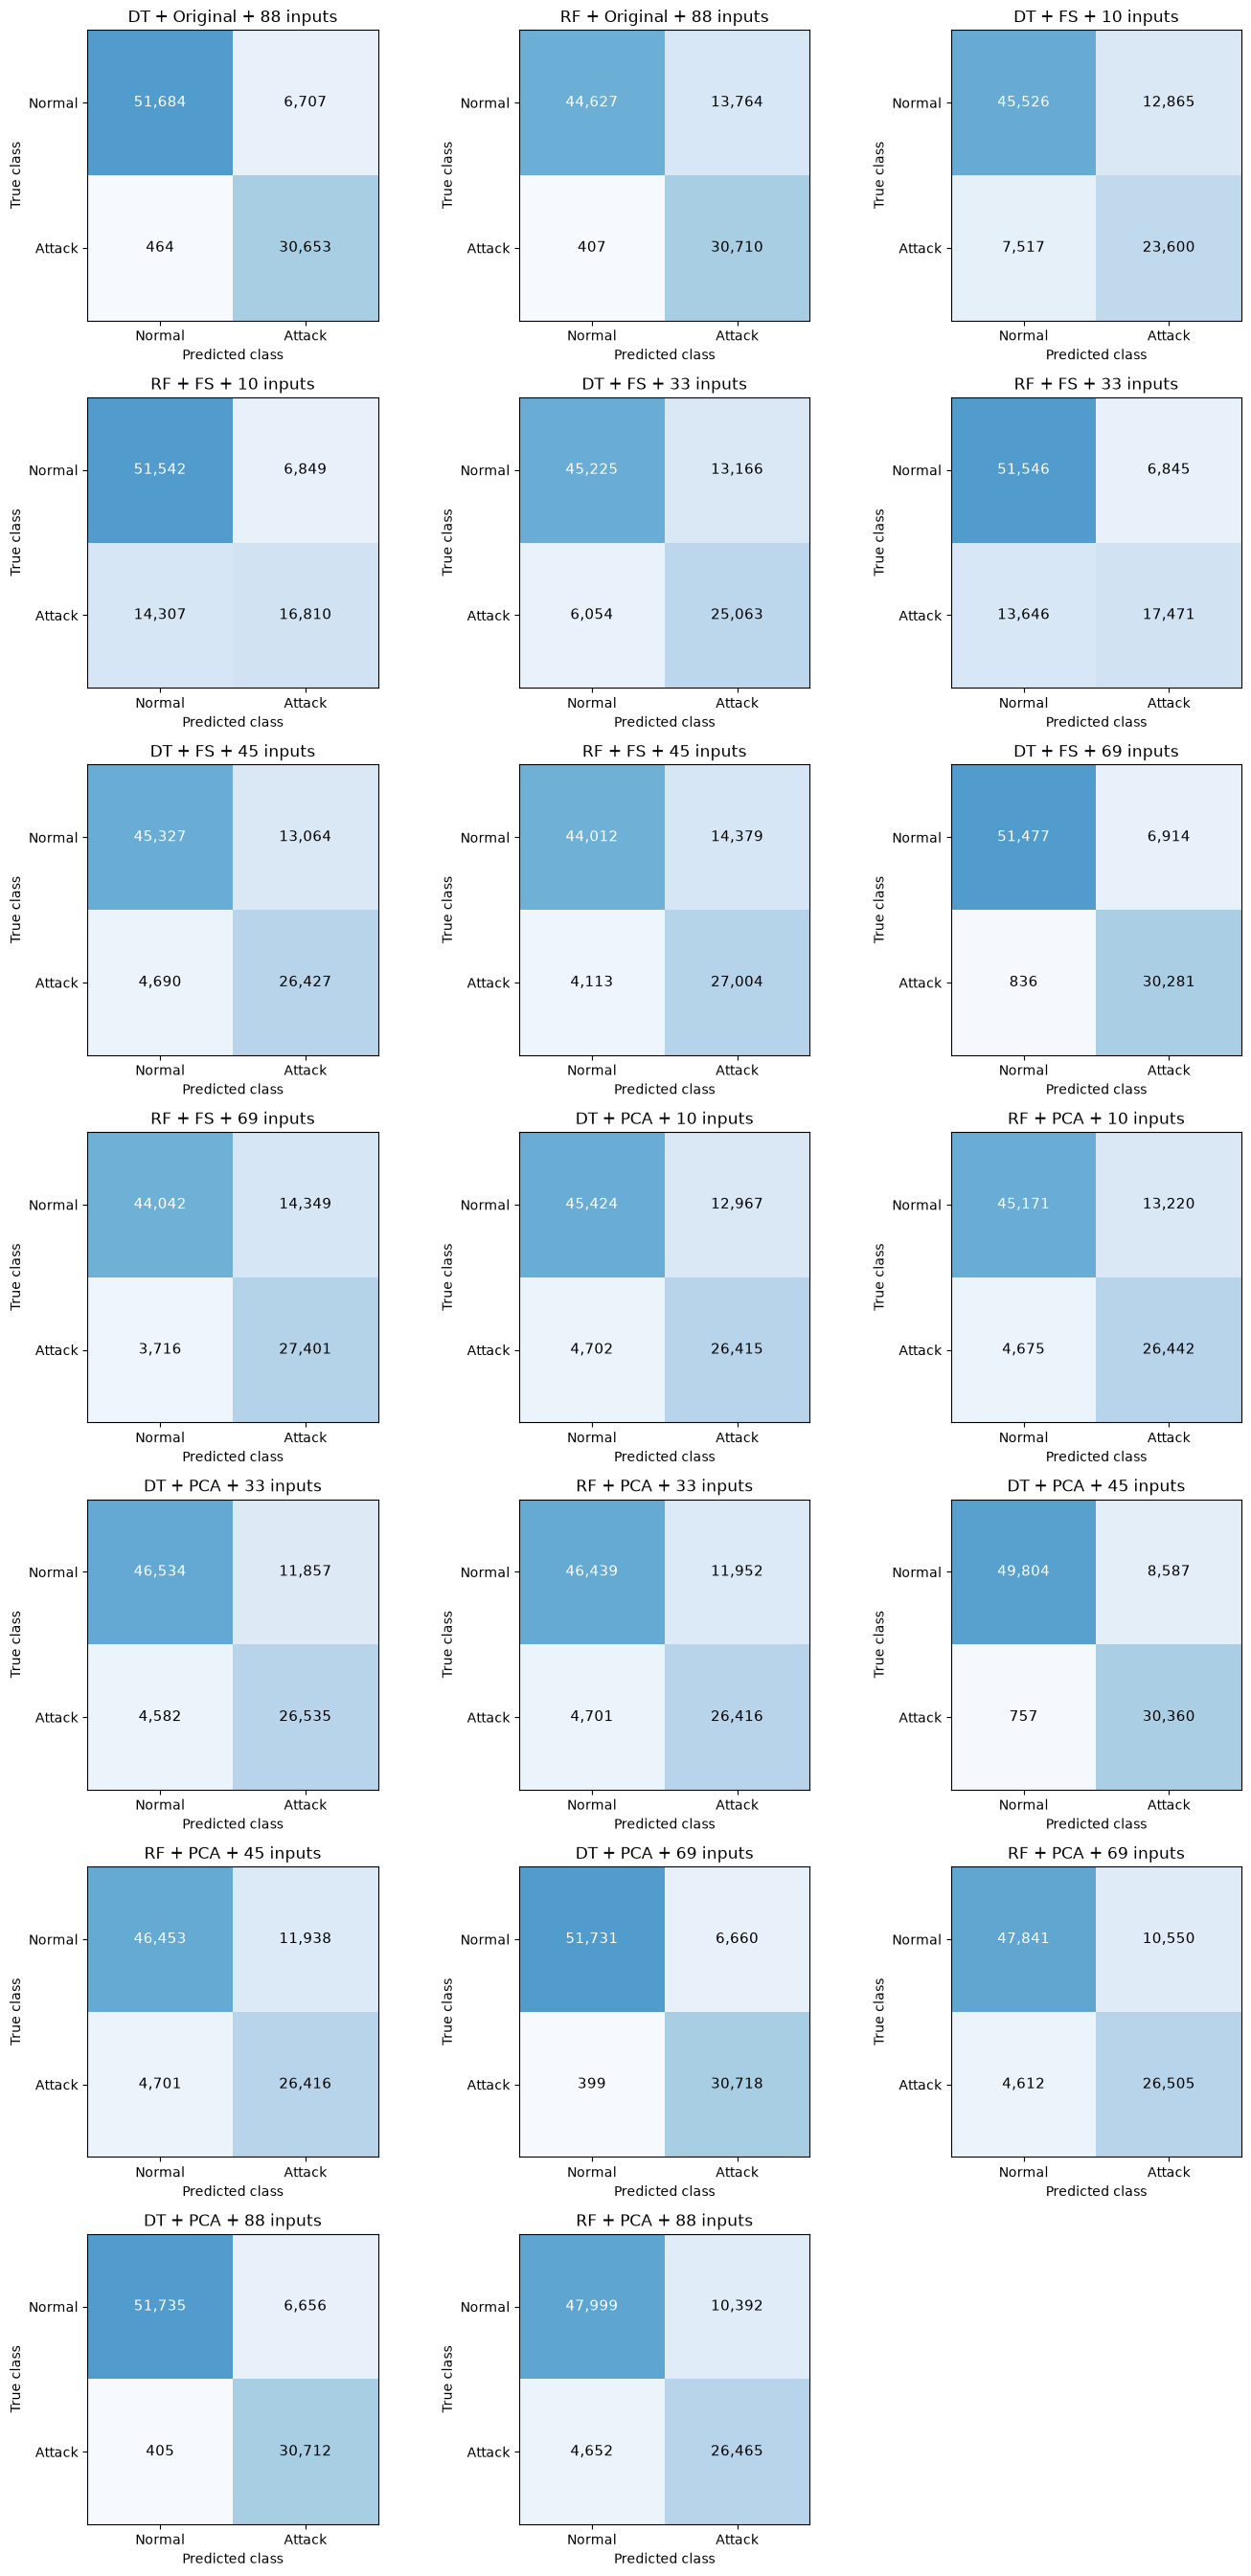

模型,输入方案,维数,TN,FP,FN,TP
DT,Original,88,51684,6707,464,30653
RF,Original,88,44627,13764,407,30710
DT,FS,10,45526,12865,7517,23600
RF,FS,10,51542,6849,14307,16810
DT,FS,33,45225,13166,6054,25063
RF,FS,33,51546,6845,13646,17471
DT,FS,45,45327,13064,4690,26427
RF,FS,45,44012,14379,4113,27004
DT,FS,69,51477,6914,836,30281
RF,FS,69,44042,14349,3716,27401


In [10]:
# 10.展示全部实验的混淆矩阵
fig_confusion, axes = plt.subplots(7, 3, figsize=(14, 27))
for ax, row in zip(axes.ravel(), result_rows):
    key = f"{row['模型']}_{row['输入方案']}_{row['维数']}"
    matrix = confusion_matrix(y_test, predictions[key], labels=[0, 1])
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=len(y_test))
    for (i, j), count in np.ndenumerate(matrix):
        ax.text(j, i, f"{count:,}", ha="center", va="center",
                color="white" if count > len(y_test) * 0.45 else "black", fontsize=11)
    ax.set_xticks([0, 1], ["Normal", "Attack"])
    ax.set_yticks([0, 1], ["Normal", "Attack"])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(f"{row['模型']} + {row['输入方案']} + {row['维数']} inputs")
for ax in axes.ravel()[len(result_rows):]:
    ax.set_visible(False)
fig_confusion.tight_layout()
plt.show()
confusion_counts = results_summary[["模型", "输入方案", "维数", "TN", "FP", "FN", "TP"]]
show_table(confusion_counts)

结论：全部 20 个混淆矩阵和计数表使用同一批预测。四类计数覆盖完整测试集。FP（正常误报），FN（攻击漏报），二者需要同时比较。

混淆矩阵将所有攻击合并统计，无法显示各攻击类型的漏报情况。02 已保留每条测试记录的攻击类型，所以接下来按全部九种攻击类型分别统计检出和漏报。

当前模型只判断正常或攻击。某条攻击记录被预测为攻击，就计为检出。但是这不表示模型正确识别了具体攻击名称。各类型召回率等于该类型的检出数除以测试记录数。正常记录的误报已经在上一步统计。

In [11]:
# 11.统计全部九种攻击类型的检出与漏报
# 只统计攻击类型，正常误报已经在上一步核对
attack_types = sorted(set(test_type) - {"normal"})
attack_recall_rows = []
for row in result_rows:
    key = f"{row['模型']}_{row['输入方案']}_{row['维数']}"
    predicted = predictions[key]
    for traffic_type in attack_types:
        mask = test_type == traffic_type
        total = int(mask.sum())
        detected = int((predicted[mask] == 1).sum())
        attack_recall_rows.append({
            "模型": row["模型"], "输入方案": row["输入方案"], "维数": row["维数"],
            "攻击类型": traffic_type, "测试记录数": total, "检出数": detected,
            "漏报数": total - detected, "攻击类型召回率": detected / total,
        })
attack_type_results = pd.DataFrame(attack_recall_rows)
assert len(attack_type_results) == len(result_rows) * len(attack_types)
for _, block in attack_type_results.groupby(["模型", "输入方案", "维数"]):
    assert block["测试记录数"].sum() == int((y_test == 1).sum())
show_table(attack_type_results)

模型,输入方案,维数,攻击类型,测试记录数,检出数,漏报数,攻击类型召回率
DT,Original,88,backdoor,4000,3998,2,0.999500
DT,Original,88,ddos,4000,3981,19,0.995250
DT,Original,88,dos,4000,3981,19,0.995250
DT,Original,88,injection,4000,3987,13,0.996750
DT,Original,88,mitm,209,187,22,0.894737
DT,Original,88,password,4000,3987,13,0.996750
DT,Original,88,ransomware,4000,3715,285,0.928750
DT,Original,88,scanning,3277,3256,21,0.993592
DT,Original,88,xss,3631,3561,70,0.980722
RF,Original,88,backdoor,4000,3999,1,0.999750


结论：全部 20 个实验在九种攻击类型上的检出和漏报均已展示，共 180 条结果。各类型测试数量不同，mitm 为 209 条。类型检出率不代表模型识别了具体攻击名称。

表格可以核对数值，但不便于直观看出方案间的效果与开销变化。所以下一步根据第 9 步的汇总表绘制对照图。

本项目关注两类的综合检测表现、攻击漏报及计算开销，所以图中选择 Macro-F1、攻击召回率、训练总时间和测试总时间。图示只覆盖这四个角度。攻击精确率、Accuracy、Weighted-F1 和 MCC 仍完整保留在汇总表中。

DT、RF 各展示全部十种输入方案。颜色固定为 Original 蓝色、FS 橙色、PCA 绿色。


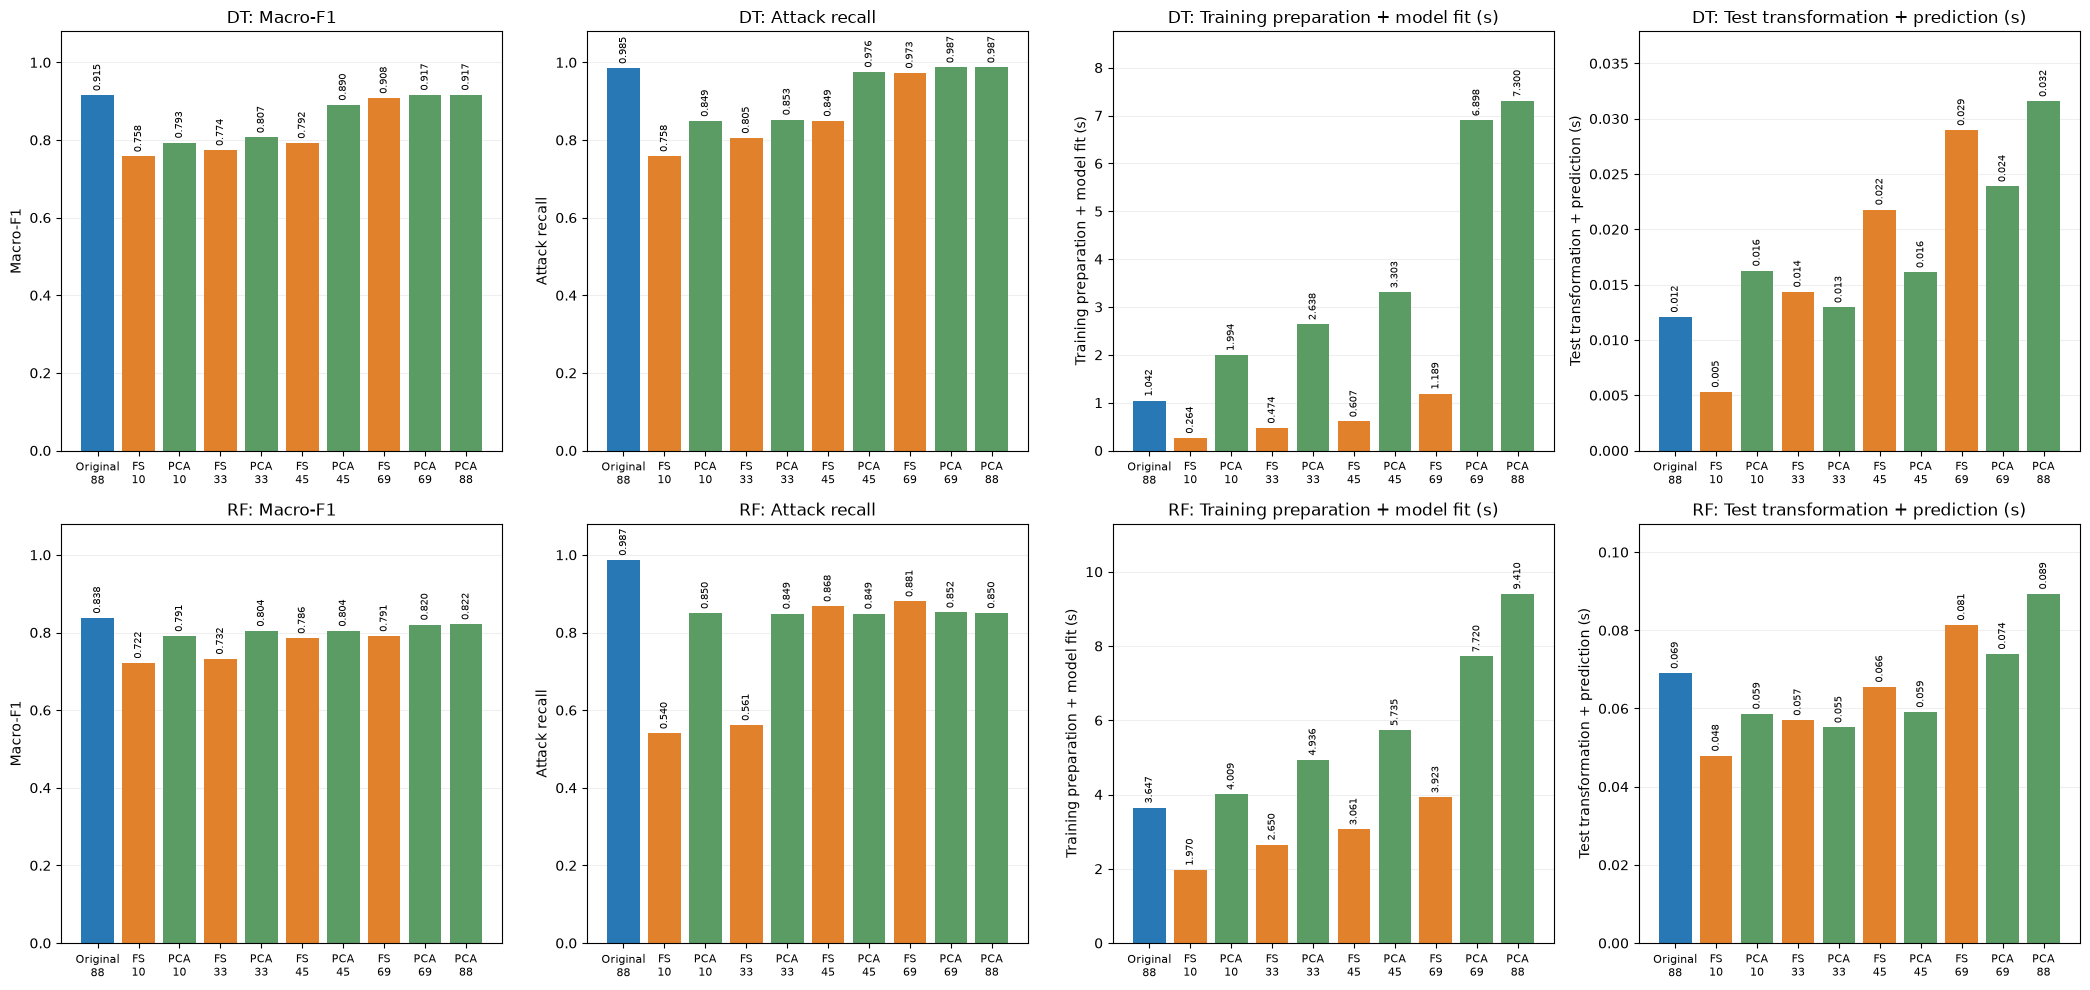

In [12]:
# 12.绘制全部输入方案的性能与耗时对照
scheme_order = [("Original", 88)]
for dimensions in fs_inputs:
    scheme_order.extend([("FS", dimensions), ("PCA", dimensions)])
scheme_order.append(("PCA", len(feature_names)))
labels = [f"{method}\n{dimensions}" for method, dimensions in scheme_order]
fig_comparison, axes = plt.subplots(2, 4, figsize=(21, 10))
plot_metrics = [("Macro-F1", "Macro-F1"), ("攻击召回率", "Attack recall"),
                ("训练总秒", "Training preparation + model fit (s)"),
                ("测试总秒", "Test transformation + prediction (s)")]
colors = {"Original": "#2878B5", "FS": "#E1812C", "PCA": "#5B9B64"}
for row_position, model_name in enumerate(model_factories):
    subset = results_summary[results_summary["模型"] == model_name].set_index(["输入方案", "维数"])
    for column_position, (metric, label) in enumerate(plot_metrics):
        ax = axes[row_position, column_position]
        values = [subset.loc[(method, dimensions), metric] for method, dimensions in scheme_order]
        bars = ax.bar(np.arange(len(labels)), values,
                      color=[colors[method] for method, _ in scheme_order])
        ax.set_xticks(np.arange(len(labels)), labels, fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f"{model_name}: {label}")
        if column_position < 2:
            ax.set_ylim(0, 1.08)
        else:
            ax.set_ylim(0, max(values) * 1.2)
        ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=3, rotation=90)
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)
fig_comparison.tight_layout()
plt.show()

结论：图中覆盖 DT、RF 各自的全部十种输入方案。PCA 88 维不减少列数，其余 PCA 方案减少输入数量。检测分数与时间分别展示，不能仅凭维数判断速度。单次计时只描述本次运行，04 将重复测量。

为了让 04 独立核对这些结果，下一步保存完整表格、预测、参数与图形，再重新读取检查。


In [13]:
# 13.保存完整结果并核对结果表和预测数组
import os
import tempfile

assert hashlib.sha256(X_train.tobytes()).hexdigest() == train_digest
assert hashlib.sha256(X_test.tobytes()).hexdigest() == test_digest
assert hashlib.sha256(input_path.read_bytes()).hexdigest() == input_sha256
output_dir = root / "results" / "03_features_and_models"
figure_dir = output_dir / "figures"
for folder in ["figures", "tables", "arrays", "metadata"]:
    (output_dir / folder).mkdir(parents=True, exist_ok=True)

def save_csv(table, name, index=False):
    target = output_dir / name
    temporary_path = None
    try:
        with tempfile.NamedTemporaryFile(mode="w", encoding="utf-8-sig", newline="",
                                         dir=output_dir, suffix=".csv", delete=False) as temporary:
            temporary_path = Path(temporary.name)
            table.to_csv(temporary, index=index)
        os.replace(temporary_path, target)
    finally:
        if temporary_path is not None and temporary_path.exists():
            temporary_path.unlink()
    return target

tables_to_save = {
    "tables/results_summary.csv": results_summary,
    "tables/fs_pca_comparison.csv": paired_comparison,
    "tables/full_pca_comparison.csv": full_pca_comparison,
    "tables/model_parameters.csv": model_parameters,
    "tables/model_diagnostics.csv": model_diagnostics,
    "tables/input_distribution.csv": type_distribution,
    "tables/feature_scores.csv": feature_scores,
    "tables/fs_thresholds.csv": threshold_summary,
    "tables/fs_selected_features.csv": selected_features,
    "tables/pca_variance.csv": pca_variance,
    "tables/pca_loadings.csv": pca_loadings,
    "tables/attack_type_recall.csv": attack_type_results,
}
table_descriptions = {
    "tables/results_summary.csv": "全部实验的指标、耗时及相对基线的变化",
    "tables/fs_pca_comparison.csv": "同模型、同维数下 PCA 与 FS 的差值",
    "tables/full_pca_comparison.csv": "PCA 完整维数与 Original 的差值",
    "tables/model_parameters.csv": "DT 和 RF 的完整参数设置",
    "tables/model_diagnostics.csv": "训练与测试分数、树数量、树深和叶子数",
    "tables/input_distribution.csv": "训练集与测试集的流量类型分布",
    "tables/feature_scores.csv": "全部输入列的平均有符号 Pearson 相关分数",
    "tables/fs_thresholds.csv": "全部候选阈值及对应的入选列数",
    "tables/fs_selected_features.csv": "各阈值下的入选列名与相关分数",
    "tables/pca_variance.csv": "各主成分的方差保留比例及累计比例",
    "tables/pca_loadings.csv": "各主成分对应原始输入列的组合系数",
    "tables/attack_type_recall.csv": "全部实验按攻击类型统计的检出、漏报和召回率",
}
figure_descriptions = {
    "pearson_matrix.png": "全部输入列之间的 Pearson 相关矩阵图",
    "pca_variance.png": "各 PCA 方案的累计方差保留比例图",
    "confusion_matrices.png": "全部 20 个实验的混淆矩阵图",
    "performance_and_time.png": "DT、RF 全部输入方案的检测表现与耗时对照图",
}
artifact_rows = []
for name, table in tables_to_save.items():
    target = save_csv(table, name)
    reloaded = pd.read_csv(target)
    assert len(reloaded) == len(table) and reloaded.columns.tolist() == table.columns.tolist()
    artifact_rows.append({"文件": str(target.relative_to(root)), "内容": table_descriptions[name],
                          "记录数": len(table)})
correlation_path = save_csv(correlation_table, "tables/pearson_matrix.csv", index=True)
artifact_rows.append({"文件": str(correlation_path.relative_to(root)), "内容": "全部 Pearson 系数",
                      "记录数": len(correlation_table)})

prediction_payload = {"y_test": y_test, "test_index": test_index, "test_type": test_type,
                      **predictions}
prediction_path = output_dir / "arrays/test_predictions.npz"
with tempfile.NamedTemporaryFile(dir=output_dir, suffix=".npz", delete=False) as temporary:
    temporary_path = Path(temporary.name)
    np.savez_compressed(temporary, **prediction_payload)
try:
    os.replace(temporary_path, prediction_path)
finally:
    if temporary_path.exists():
        temporary_path.unlink()
with np.load(prediction_path, allow_pickle=False) as stored:
    assert set(stored.files) == set(prediction_payload)
    for key, values in prediction_payload.items():
        assert np.array_equal(stored[key], values), key
artifact_rows.append({"文件": str(prediction_path.relative_to(root)), "内容": "全部测试预测与对应标签",
                      "记录数": len(y_test)})

experiment_settings = {
    "split": "exact_input_group_holdout", "input_file": str(input_path.relative_to(root)),
    "input_sha256": input_sha256, "raw_sha256": raw_sha256,
    "train_rows": len(y_train), "test_rows": len(y_test), "original_dimensions": len(feature_names),
    "feature_names": feature_names.tolist(), "random_seed": random_seed,
    "thresholds": thresholds, "fs_dimensions": list(fs_inputs), "pca_dimensions": pca_dimensions,
    "score_definition": "signed Pearson column mean including self correlation",
    "pca": {"input": "Min-Max from 02", "solver": "full", "whiten": False},
    "model_parameters": {name: factory().get_params() for name, factory in model_factories.items()},
    "timing": {"train_total": "representation preparation plus estimator fit",
               "test_total": "representation transformation plus estimator prediction",
               "excluded": ["02 preparation", "file input/output", "metrics", "plots"],
               "linear_algebra_threads": 4,
               "diagnostic_prediction": "training predictions in model diagnostics excluded",
               "fs_score_time": "one full score computation allocated to each standalone FS candidate"},
    "versions": {"python": platform.python_version(), "numpy": np.__version__,
                 "pandas": pd.__version__, "sklearn": sklearn.__version__, "matplotlib": matplotlib.__version__},
    "result_rows": len(results_summary),
}
settings_path = output_dir / "metadata/experiment_settings.json"
settings_path.write_text(json.dumps(experiment_settings, ensure_ascii=False, indent=2) + "\n",
                         encoding="utf-8")
artifact_rows.append({"文件": str(settings_path.relative_to(root)), "内容": "数据版本和完整实验设置",
                      "记录数": 1})
for figure, name in [(fig_correlation, "pearson_matrix.png"), (fig_variance, "pca_variance.png"),
                     (fig_confusion, "confusion_matrices.png"), (fig_comparison, "performance_and_time.png")]:
    target = figure_dir / name
    figure.savefig(target, dpi=160, bbox_inches="tight")
    artifact_rows.append({"文件": str(target.relative_to(root)), "内容": figure_descriptions[name], "记录数": 1})
restored_results = pd.read_csv(output_dir / "tables/results_summary.csv")
for column in ["维数", "TN", "FP", "FN", "TP", "随机种子"]:
    np.testing.assert_array_equal(restored_results[column], results_summary[column])
for column in ["Macro-F1", "攻击召回率", "攻击精确率", "Accuracy", "Weighted-F1", "MCC",
               "训练准备秒", "测试转换秒", "模型训练秒", "模型预测秒", "训练总秒", "测试总秒"]:
    np.testing.assert_allclose(restored_results[column], results_summary[column], rtol=1e-12, atol=1e-12)
show_table(pd.DataFrame(artifact_rows))

文件,内容,记录数
results/03_features_and_models/tables/results_summary.csv,全部实验的指标、耗时及相对基线的变化,20
results/03_features_and_models/tables/fs_pca_comparison.csv,同模型、同维数下 PCA 与 FS 的差值,8
results/03_features_and_models/tables/full_pca_comparison.csv,PCA 完整维数与 Original 的差值,2
results/03_features_and_models/tables/model_parameters.csv,DT 和 RF 的完整参数设置,32
results/03_features_and_models/tables/model_diagnostics.csv,训练与测试分数、树数量、树深和叶子数,20
results/03_features_and_models/tables/input_distribution.csv,训练集与测试集的流量类型分布,10
results/03_features_and_models/tables/feature_scores.csv,全部输入列的平均有符号 Pearson 相关分数,88
results/03_features_and_models/tables/fs_thresholds.csv,全部候选阈值及对应的入选列数,5
results/03_features_and_models/tables/fs_selected_features.csv,各阈值下的入选列名与相关分数,245
results/03_features_and_models/tables/pca_variance.csv,各主成分的方差保留比例及累计比例,245


结论：完整结果已保存到 `results/03_features_and_models`，包含 20 个实验、全部预测和完整维数 PCA 对照。保存后的预测与各项指标已重新读取核对。

这些结果使用一次隔离划分和模型种子 42。单次分数与耗时不足以说明稳定性，所以 04 接着核对结果，并分别检查模型种子、重复计时和重新隔离划分的影响。
